In [1]:
import os, json, shutil
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd
from scipy.ndimage import label as cc_label
from scipy.stats import spearmanr
from medpy.metric.binary import hd95 as medpy_hd95

SPLITS_DIR = Path(r"D:\master_experiments\data\splits\BraTS2020_Splits")
META_PATH = SPLITS_DIR / "splits_metadata.json"

NNUNET_BASE = Path(r"D:\master_experiments\models_configs\nnUNet_ResEnc_2020")
NNUNET_RAW = NNUNET_BASE / "nnUNet_raw"
NNUNET_PREP = NNUNET_BASE / "nnUNet_preprocessed"
NNUNET_RES = NNUNET_BASE / "nnUNet_results"

for p in [NNUNET_RAW, NNUNET_PREP, NNUNET_RES]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREP)
os.environ["nnUNet_results"] = str(NNUNET_RES)

DATASET_ID = 904
DATASET_NAME = "BraTS2020_ResEnc_4ch"
DATASET_FOLDER = NNUNET_RAW / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

for p in [imagesTr, labelsTr, imagesTs]:
    p.mkdir(parents=True, exist_ok=True)

# Configuração ResEnc nnUNetv2
PLANNER    = "nnUNetPlannerResEncM"        # Medium ResEnc (recomendação atual é 24GB VRAM) troquei para o M para rodar local
PLANS_NAME = "nnUNetResEncUNetMPlans"    
TRAINER    = "nnUNetTrainer_100epochs"     # 100 épocas normal é 1000
CONFIG     = "3d_fullres"
FOLD       = 0

SPLITS_DIR.exists(), META_PATH.exists(), DATASET_FOLDER

(True,
 True,
 WindowsPath('D:/master_experiments/models_configs/nnUNet_ResEnc_2020/nnUNet_raw/Dataset904_BraTS2020_ResEnc_4ch'))

In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids = meta["ids"]["val"]
test_ids = meta["ids"]["test"]

train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("Counts:", len(train_ids), len(val_ids), len(test_ids))
print("OK: sem repetição entre splits")

Counts: 245 52 53
OK: sem repetição entre splits


In [3]:
MODS = ["flair", "t1", "t1ce", "t2"]
FILE_ENDING = ".nii.gz"

def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1":
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def save_as_niigz(src_path: Path, dst_path: Path):
    if src_path.name.lower().endswith(".nii.gz"):
        shutil.copy2(src_path, dst_path)
        return
    img = nib.load(str(src_path))
    nib.save(img, str(dst_path))

def save_label_remap_niigz(seg_path: Path, dst_path: Path):
    img = nib.load(str(seg_path))
    data = np.asanyarray(img.dataobj).astype(np.int16)
    data[data == 4] = 3
    out = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(out, str(dst_path))

def check_case(split_name: str, case_id: str):
    d = case_dir(split_name, case_id)
    assert d.exists(), f"Missing folder: {d}"
    _ = [find_file(d, m) for m in MODS]
    _ = find_file(d, "seg")
    return True

for cid in train_ids[:3]:
    check_case("train", cid)
print("OK")

OK


In [4]:
def export_case_to_nnunet(split_name: str, case_id: str, to_images: Path, to_labels: Path | None):
    d = case_dir(split_name, case_id)
    for ch, mod in enumerate(MODS):
        src = find_file(d, mod)
        dst = to_images / f"{case_id}_{ch:04d}{FILE_ENDING}"
        save_as_niigz(src, dst)
    if to_labels is not None:
        seg = find_file(d, "seg")
        dst = to_labels / f"{case_id}{FILE_ENDING}"
        save_label_remap_niigz(seg, dst)

for cid in tqdm(train_ids, desc="Export train -> imagesTr/labelsTr"):
    export_case_to_nnunet("train", cid, imagesTr, labelsTr)

for cid in tqdm(val_ids, desc="Export val -> imagesTr/labelsTr"):
    export_case_to_nnunet("val", cid, imagesTr, labelsTr)

for cid in tqdm(test_ids, desc="Export test -> imagesTs"):
    export_case_to_nnunet("test", cid, imagesTs, None)

len(list(imagesTr.glob(f"*{FILE_ENDING}"))), len(list(labelsTr.glob(f"*{FILE_ENDING}"))), len(list(imagesTs.glob(f"*{FILE_ENDING}")))

Export test -> imagesTs: 100%|██████████| 53/53 [00:21<00:00,  2.52it/s]


(1188, 297, 212)

In [5]:
dataset_json = {
    "channel_names": {"0": "FLAIR", "1": "T1", "2": "T1ce", "3": "T2"},
    "labels": {"background": 0, "non_enhancing_and_necrosis": 1, "edema": 2, "enhancing_tumor": 3},
    "numTraining": len(list(labelsTr.glob(f"*{FILE_ENDING}"))),
    "file_ending": FILE_ENDING
}

with open(DATASET_FOLDER / "dataset.json", "w", encoding="utf-8") as f:
    json.dump(dataset_json, f, indent=2, ensure_ascii=False)

DATASET_FOLDER / "dataset.json"

WindowsPath('D:/master_experiments/models_configs/nnUNet_ResEnc_2020/nnUNet_raw/Dataset904_BraTS2020_ResEnc_4ch/dataset.json')

In [6]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity -pl {PLANNER} -c {CONFIG} -np 4

Fingerprint extraction...
Dataset904_BraTS2020_ResEnc_4ch
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...
Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [139. 170. 138.], 3d_lowres: [139, 170, 138]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 107, 'patch_size': (np.int64(192), np.int64(160)), 'median_image_size_in_voxels': array([170., 138.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization'], 'use_mask_for_norm': [True, True, True, True], 'resampling_fn_data': 'resample_dat


100%|##########| 297/297 [00:34<00:00,  8.60it/s]

100%|##########| 297/297 [05:15<00:00,  1.06s/it]


In [7]:
preprocessed_dataset = NNUNET_PREP / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
preprocessed_dataset.exists()

True

In [8]:
splits_final = [{"train": sorted(train_ids), "val": sorted(val_ids)}]
with open(preprocessed_dataset / "splits_final.json", "w", encoding="utf-8") as f:
    json.dump(splits_final, f, indent=2, ensure_ascii=False)

preprocessed_dataset / "splits_final.json"

WindowsPath('D:/master_experiments/models_configs/nnUNet_ResEnc_2020/nnUNet_preprocessed/Dataset904_BraTS2020_ResEnc_4ch/splits_final.json')

In [9]:
prep = Path(os.environ["nnUNet_preprocessed"]) / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
print("Preprocessed dir:", prep)

plans_files = list(prep.glob(f"{PLANS_NAME}*.json"))
print("Plans files:", plans_files)

if plans_files:
    with open(plans_files[0], "r", encoding="utf-8") as f:
        plans_json = json.load(f)
    print("Top keys:", plans_json.keys())

Preprocessed dir: D:\master_experiments\models_configs\nnUNet_ResEnc_2020\nnUNet_preprocessed\Dataset904_BraTS2020_ResEnc_4ch
Plans files: [WindowsPath('D:/master_experiments/models_configs/nnUNet_ResEnc_2020/nnUNet_preprocessed/Dataset904_BraTS2020_ResEnc_4ch/nnUNetResEncUNetMPlans.json')]
Top keys: dict_keys(['dataset_name', 'plans_name', 'original_median_spacing_after_transp', 'original_median_shape_after_transp', 'image_reader_writer', 'transpose_forward', 'transpose_backward', 'configurations', 'experiment_planner_used', 'label_manager', 'foreground_intensity_properties_per_channel'])


In [10]:
!nnUNetv2_train {DATASET_ID} {CONFIG} {FOLD} -device cuda -p {PLANS_NAME} -tr {TRAINER}

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-05-06 20:20:13.991707: do_dummy_2d_data_aug: False
2026-05-06 20:20:13.993707: Using splits from existing split file: D:\master_experiments\models_configs\nnUNet_ResEnc_2020\nnUNet_preprocessed\Dataset904_BraTS2020_ResEnc_4ch\splits_final.json
2026-05-06 20:20:13.994718: The split file contains 1 splits.
2026-05-06 20:20:13.995706: Desired fold for training: 0
2026-05-06 20:20:13.995706: This split has 245 training and 52 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name:

In [11]:
pattern = str(NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / "*" / f"fold_{FOLD}" / "validation" / "summary.json")
cands = glob(pattern)
cands[:2], len(cands)

(['D:\\master_experiments\\models_configs\\nnUNet_ResEnc_2020\\nnUNet_results\\Dataset904_BraTS2020_ResEnc_4ch\\nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__3d_fullres\\fold_0\\validation\\summary.json'],
 1)

In [12]:
if cands:
    with open(cands[0], "r", encoding="utf-8") as f:
        summary = json.load(f)
    list(summary.keys())

In [13]:
PRED_TEST_OUT = Path(r"D:\nnUNet_preds\brats2020_resenc_test_pred")
PRED_TEST_OUT.mkdir(parents=True, exist_ok=True)

!nnUNetv2_predict -i "{imagesTs}" -o "{PRED_TEST_OUT}" -d {DATASET_ID} -c {CONFIG} -f {FOLD} -p {PLANS_NAME} -tr {TRAINER}


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 53 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 53 cases that I would like to predict

Predicting BraTS20_Training_006:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS20_Training_006

Predicting BraTS20_Training_008:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS20_Training_008

Predicting BraTS20_Training_014:
perform_everything_on_device: True
sending off prediction t


100%|##########| 8/8 [00:04<00:00,  1.82it/s]

100%|##########| 8/8 [00:03<00:00,  2.30it/s]

100%|##########| 8/8 [00:03<00:00,  2.34it/s]

100%|##########| 8/8 [00:03<00:00,  2.34it/s]

100%|##########| 8/8 [00:03<00:00,  2.34it/s]

100%|##########| 8/8 [00:03<00:00,  2.38it/s]

100%|##########| 8/8 [00:03<00:00,  2.39it/s]

100%|##########| 4/4 [00:01<00:00,  2.49it/s]

100%|##########| 4/4 [00:01<00:00,  2.48it/s]

100%|##########| 8/8 [00:03<00:00,  2.44it/s]

100%|##########| 4/4 [00:01<00:00,  2.48it/s]

100%|##########| 4/4 [00:01<00:00,  2.47it/s]

100%|##########| 8/8 [00:03<00:00,  2.43it/s]

100%|##########| 8/8 [00:03<00:00,  2.44it/s]

100%|##########| 8/8 [00:03<00:00,  2.44it/s]

100%|##########| 8/8 [00:03<00:00,  2.43it/s]

100%|##########| 4/4 [00:01<00:00,  2.47it/s]

100%|##########| 8/8 [00:03<00:00,  2.44it/s]

100%|##########| 8/8 [00:03<00:00,  2.43it/s]

100%|##########| 8/8 [00:03<00:00,  2.44it/s]

100%|##########| 4/4 [00:01<00:00,  2.48it/s]

100%|#######

In [14]:
def load_arr(p: Path):
    return np.asanyarray(nib.load(str(p)).dataobj)

def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def get_pred_path(cid: str):
    p = PRED_TEST_OUT / f"{cid}.nii.gz"
    if p.exists():
        return p
    p = PRED_TEST_OUT / f"{cid}.nii"
    if p.exists():
        return p
    raise FileNotFoundError(f"Pred não encontrada para {cid}")

rows = []
for cid in tqdm(test_ids, desc="Dice por caso"):
    gt_path = find_file(case_dir("test", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    gt[gt == 4] = 3  # BraTS2020: remap 4->3
    pr = load_arr(pr_path).astype(np.int16)
    pr[pr == 4] = 3

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)

    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))

    rows.append({
        "id": cid,
        "dice_c1": d1,
        "dice_c2": d2,
        "dice_ET": d3,
        "dice_WT": wt,
        "dice_TC": tc,
    })

df = pd.DataFrame(rows)
df.describe()

Dice por caso: 100%|██████████| 53/53 [00:06<00:00,  8.74it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.745435,0.833321,0.825371,0.909518,0.908951
std,0.215676,0.108440,0.188626,0.071209,0.078647
min,0.070103,0.497300,0.025316,0.671353,0.625794
25%,0.644804,0.792038,0.818010,0.898712,0.895014
50%,0.815225,0.869000,0.892272,0.933601,0.936667
75%,0.910425,0.912741,0.927191,0.952979,0.958648
max,0.985966,0.964666,0.963293,0.976009,0.984856


In [15]:
# HD95 (Hausdorff Distance 95) por caso — mesmo padrão do Dice global por regiões

def hd95_score(gt_mask, pr_mask, voxelspacing=None):
    gt_b = gt_mask.astype(bool)
    pr_b = pr_mask.astype(bool)
    if not gt_b.any() and not pr_b.any():
        return 0.0
    if not gt_b.any() or not pr_b.any():
        return np.nan
    return float(medpy_hd95(pr_b, gt_b, voxelspacing=voxelspacing))


hd95_rows = []
for cid in tqdm(test_ids, desc="HD95 por caso"):
    gt_path = find_file(case_dir("test", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    gt[gt == 4] = 3  # BraTS2020: remap 4->3
    pr = load_arr(pr_path).astype(np.int16)
    pr[pr == 4] = 3

    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]

    h1  = hd95_score(gt == 1, pr == 1, voxelspacing=spacing)
    h2  = hd95_score(gt == 2, pr == 2, voxelspacing=spacing)
    h3  = hd95_score(gt == 3, pr == 3, voxelspacing=spacing)
    hwt = hd95_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)), voxelspacing=spacing)
    htc = hd95_score(((gt == 1) | (gt == 3)),   ((pr == 1) | (pr == 3)),   voxelspacing=spacing)

    hd95_rows.append({
        "id":       cid,
        "hd95_c1":  h1,
        "hd95_c2":  h2,
        "hd95_ET":  h3,
        "hd95_WT":  hwt,
        "hd95_TC":  htc,
    })

df_hd95 = pd.DataFrame(hd95_rows)
df_hd95.describe()

HD95 por caso: 100%|██████████| 53/53 [04:41<00:00,  5.31s/it]


,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,4.290232,5.473172,3.242414,5.044545,3.087769
std,3.427333,7.065560,4.796095,6.315554,3.543083
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.732051,1.000000,1.414214,1.414214
50%,3.316625,2.449490,1.000000,2.449490,1.414214
75%,5.830952,5.385165,2.236068,5.196152,3.162278
max,15.877626,33.391616,22.143593,32.388269,16.278821


In [16]:
# Análise condicional 1/3: Frequência de presença por classe no GT

presence_rows = []
for cid in tqdm(test_ids, desc="Presença GT"):
    gt = load_arr(find_file(case_dir("test", cid), "seg")).astype(np.int16)
    gt[gt == 4] = 3  
    presence_rows.append({
        "id":      cid,
        "has_c1":  bool((gt == 1).any()),
        "has_c2":  bool((gt == 2).any()),
        "has_ET":  bool((gt == 3).any()),
        "has_WT":  bool(((gt == 1) | (gt == 2) | (gt == 3)).any()),
        "has_TC":  bool(((gt == 1) | (gt == 3)).any()),
    })
pres_df = pd.DataFrame(presence_rows)
df_full = df.merge(pres_df, on="id")

df_presence = pd.DataFrame([
    {"classe":     col,
     "n_presente": int(df_full[col].sum()),
     "n_total":    len(df_full),
     "pct":        100.0 * df_full[col].sum() / len(df_full)}
    for col in ["has_c1", "has_c2", "has_ET", "has_WT", "has_TC"]
])
df_presence.round(2)

Presença GT: 100%|██████████| 53/53 [00:02<00:00, 23.68it/s]


,classe,n_presente,n_total,pct
0,has_c1,53,53,100.0
1,has_c2,53,53,100.0
2,has_ET,53,53,100.0
3,has_WT,53,53,100.0
4,has_TC,53,53,100.0


In [17]:
# Análise condicional 2/3: Dice CONDICIONAL (apenas casos com classe presente no GT)

pairs = [("dice_c1","has_c1"), ("dice_c2","has_c2"), ("dice_ET","has_ET"),
         ("dice_WT","has_WT"), ("dice_TC","has_TC")]
df_conditional = pd.DataFrame({
    col: df_full.loc[df_full[has], col].reset_index(drop=True)
    for col, has in pairs
})
df_conditional.describe().round(4)

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.0000,53.0000,53.0000,53.0000,53.0000
mean,0.7454,0.8333,0.8254,0.9095,0.9090
std,0.2157,0.1084,0.1886,0.0712,0.0786
min,0.0701,0.4973,0.0253,0.6714,0.6258
25%,0.6448,0.7920,0.8180,0.8987,0.8950
50%,0.8152,0.8690,0.8923,0.9336,0.9367
75%,0.9104,0.9127,0.9272,0.9530,0.9586
max,0.9860,0.9647,0.9633,0.9760,0.9849


In [18]:
# Análise condicional 3/3: Bimodalidade (% de Dice=0 e % de Dice≈1, sobre todos os casos)

pairs = [("dice_c1","has_c1"), ("dice_c2","has_c2"), ("dice_ET","has_ET"),
         ("dice_WT","has_WT"), ("dice_TC","has_TC")]
df_bimodality = pd.DataFrame([
    {"metric":         col,
     "pct_dice_zero": float((df_full[col] == 0.0).mean()) * 100,
     "pct_dice_one":  float((df_full[col] >= 0.999).mean()) * 100}
    for col, _ in pairs
])
df_bimodality.round(2)

,metric,pct_dice_zero,pct_dice_one
0,dice_c1,0.0,0.0
1,dice_c2,0.0,0.0
2,dice_ET,0.0,0.0
3,dice_WT,0.0,0.0
4,dice_TC,0.0,0.0


In [19]:
# Lesion-wise Dice (LWD) — métrica primária do BraTS 2023+

LW_MIN_SIZE = 50 

def lesion_wise_dice(gt_mask: np.ndarray, pr_mask: np.ndarray, min_size: int = LW_MIN_SIZE) -> float:
    structure = np.ones((3, 3, 3), dtype=int) 
    if not gt_mask.any() and not pr_mask.any():
        return 1.0
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)

    dice_list = []
    matched_pred = set()

    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap_ids = np.unique(pr_lab[gt_l])
        overlap_ids = overlap_ids[overlap_ids > 0]
        if len(overlap_ids) == 0:
            dice_list.append(0.0) 
        else:
            pr_match = np.isin(pr_lab, overlap_ids)
            inter = np.logical_and(gt_l, pr_match).sum()
            denom = gt_l.sum() + pr_match.sum()
            dice_list.append(2.0 * inter / denom if denom > 0 else 0.0)
            matched_pred.update(int(p) for p in overlap_ids)

    for p in range(1, n_pr + 1):
        if p in matched_pred:
            continue
        pr_l = (pr_lab == p)
        if pr_l.sum() < min_size:
            continue
        dice_list.append(0.0)

    return float(np.mean(dice_list)) if dice_list else 1.0


lw_rows = []
for cid in tqdm(test_ids, desc="Lesion-wise Dice"):
    gt = load_arr(find_file(case_dir("test", cid), "seg")).astype(np.int16)
    gt[gt == 4] = 3  # BraTS2020: remap 4->3
    pr = load_arr(get_pred_path(cid)).astype(np.int16)
    pr[pr == 4] = 3

    gt_wt = (gt == 1) | (gt == 2) | (gt == 3)
    pr_wt = (pr == 1) | (pr == 2) | (pr == 3)
    gt_tc = (gt == 1) | (gt == 3)
    pr_tc = (pr == 1) | (pr == 3)
    gt_et = (gt == 3)
    pr_et = (pr == 3)

    lw_rows.append({
        "id":     cid,
        "lwd_WT": lesion_wise_dice(gt_wt, pr_wt),
        "lwd_TC": lesion_wise_dice(gt_tc, pr_tc),
        "lwd_ET": lesion_wise_dice(gt_et, pr_et),
    })

lw_df = pd.DataFrame(lw_rows)
lw_df[["lwd_WT", "lwd_TC", "lwd_ET"]].describe().round(4)

Lesion-wise Dice: 100%|██████████| 53/53 [00:45<00:00,  1.16it/s]


,lwd_WT,lwd_TC,lwd_ET
count,53.0000,53.0000,53.0000
mean,0.7062,0.8779,0.7695
std,0.2917,0.1419,0.2381
min,0.1190,0.2360,0.0385
25%,0.4597,0.8487,0.7558
50%,0.8766,0.9299,0.8740
75%,0.9474,0.9585,0.9252
max,0.9760,0.9849,0.9633


Lendo histórico de: D:\master_experiments\models_configs\nnUNet_ResEnc_2020\nnUNet_results\Dataset904_BraTS2020_ResEnc_4ch\nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__3d_fullres\fold_0\checkpoint_final.pth
Épocas registradas: train=100 | val=100


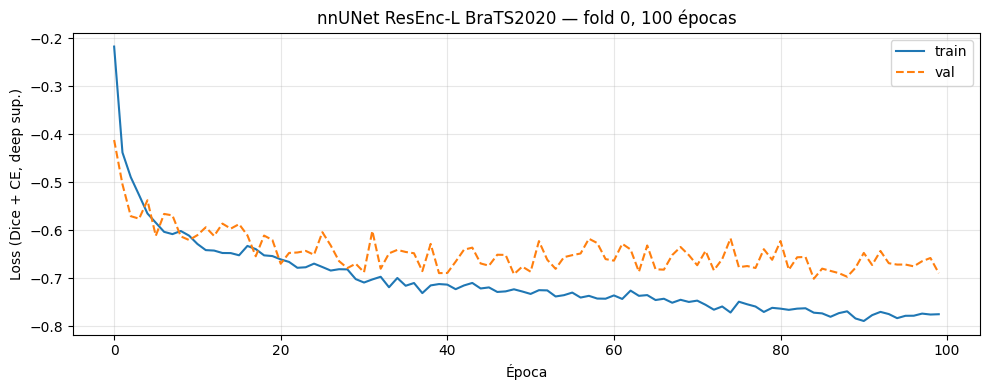

In [20]:
# Curvas de loss (treino vs validação)

import torch

trainer_dir = NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / f"{TRAINER}__{PLANS_NAME}__{CONFIG}" / f"fold_{FOLD}"

ckpt_path = trainer_dir / "checkpoint_final.pth"
if not ckpt_path.exists():
    ckpt_path = trainer_dir / "checkpoint_best.pth"
print("Lendo histórico de:", ckpt_path)

ckpt = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
log = ckpt.get("logging", {})
train_losses = log.get("train_losses", [])
val_losses   = log.get("val_losses",   [])
print(f"Épocas registradas: train={len(train_losses)} | val={len(val_losses)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val", ls="--")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (Dice + CE, deep sup.)")
ax.set_title(f"nnUNet ResEnc-L BraTS2020 — fold {FOLD}, {len(train_losses)} épocas")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(trainer_dir / "loss_curves.png", dpi=150)
plt.show()


Paciente: BraTS20_Training_151 | split=test | z=87
Dice C1 (necrose/non-enh): 0.8976
Dice C2 (edema):           0.8932
Dice ET (enhancing):       0.9363
Dice WT:                   0.9349
Dice TC:                   0.9652



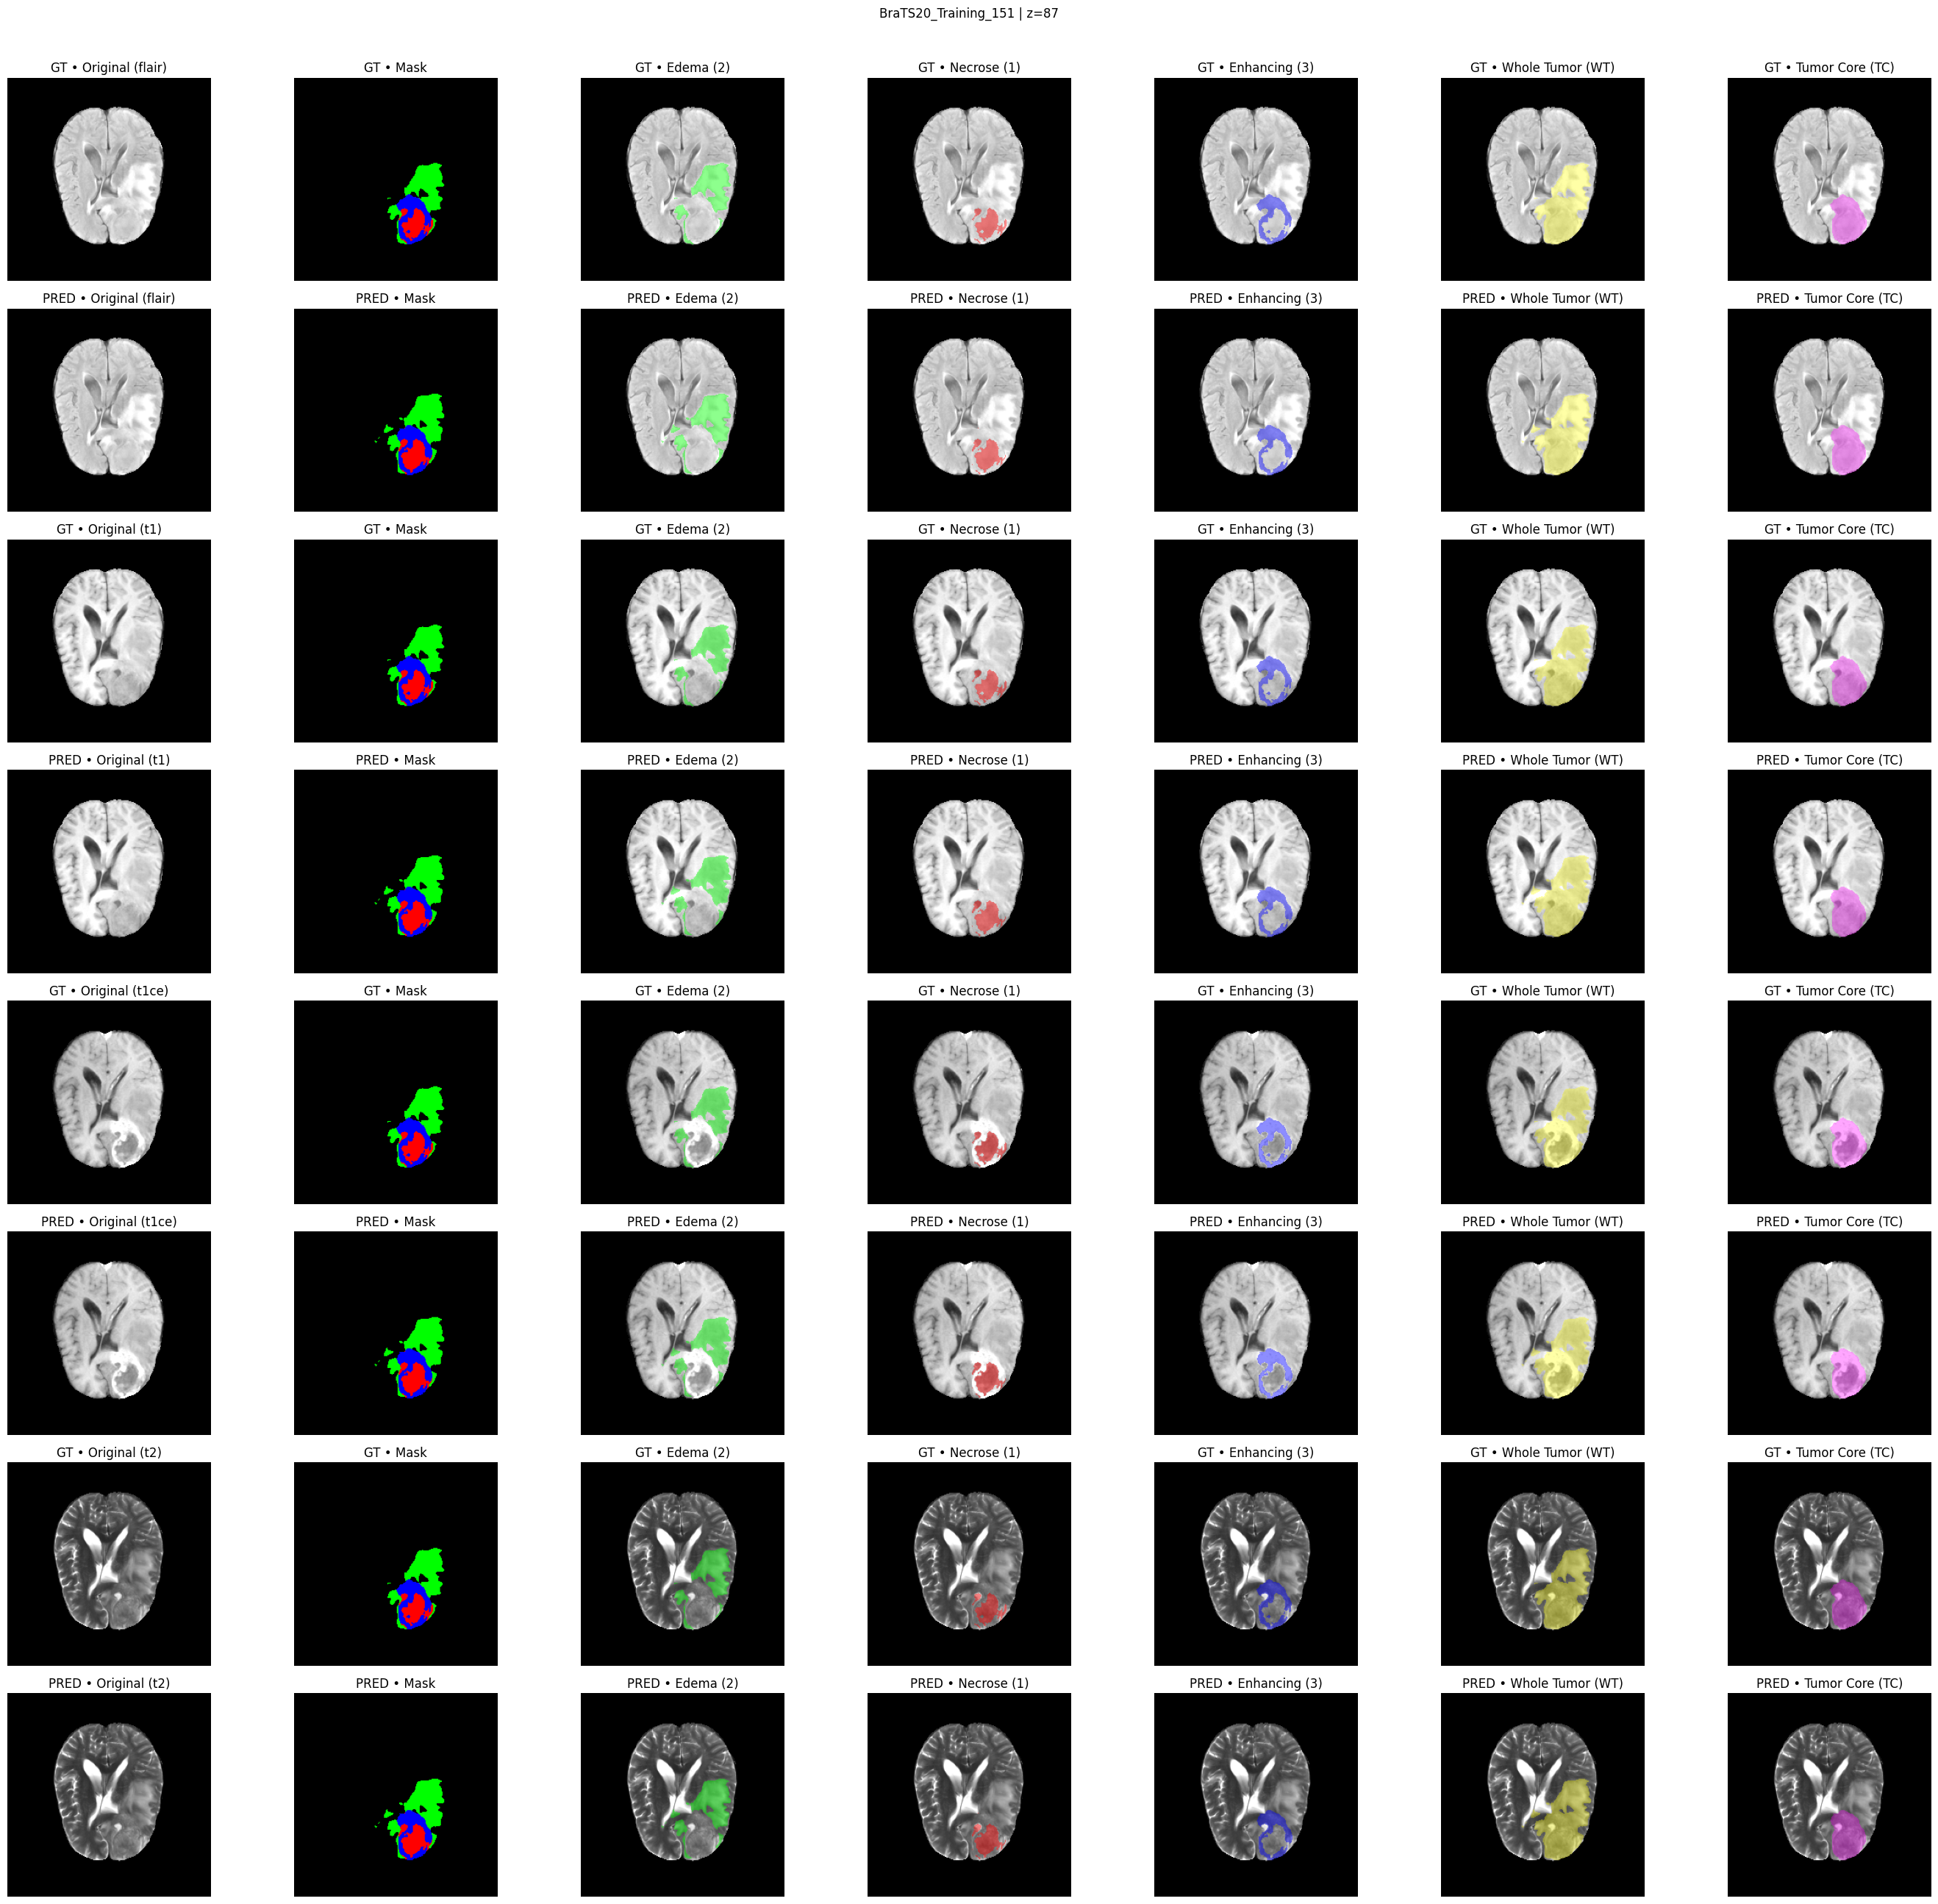

In [21]:
def norm01(x, p1=1, p99=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1)

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((mask2d.shape[0], mask2d.shape[1], 4), dtype=np.float32)
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = color_rgb
    rgba[..., 3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title)
    ax.axis("off")

def load_arr(p):
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    return np.squeeze(arr) 

def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(gt):
    counts = (gt > 0).sum(axis=(0, 1))
    return int(counts.argmax())

cmap_mask = ListedColormap([
    (0, 0, 0, 1),
    (1, 0, 0, 1),
    (0, 1, 0, 1),
    (0, 0, 1, 1),
])
norm_mask = BoundaryNorm([0, 1, 2, 3, 4], cmap_mask.N)

def masks_from_seg(seg): 
    nec = (seg == 1)
    ede = (seg == 2)
    enh = (seg == 3)
    wt  = (seg == 1) | (seg == 2) | (seg == 3)
    tc  = (seg == 1) | (seg == 3)
    return nec, ede, enh, wt, tc

def plot_random_case_multimodal_gt_pred(  
    ids_list,
    split_name="test",
    seed=None,
    z=None,
    alpha_cls=0.45,
    alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))

    d = case_dir(split_name, cid)

    gt_path = find_file(d, "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    gt[gt == 4] = 3
    pr[pr == 4] = 3

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose/non-enh): {d1:.4f}")
    print(f"Dice C2 (edema):           {d2:.4f}")
    print(f"Dice ET (enhancing):       {d3:.4f}")
    print(f"Dice WT:                   {wt:.4f}")
    print(f"Dice TC:                   {tc:.4f}\n")

    gt2d = gt[:, :, z].T
    pr2d = pr[:, :, z].T

    gt_nec, gt_ede, gt_enh, gt_wt, gt_tc = masks_from_seg(gt2d)
    pr_nec, pr_ede, pr_enh, pr_wt, pr_tc = masks_from_seg(pr2d)

    n_mods = len(MODS)
    nrows = 2 * n_mods
    ncols = 7

    fig, axes = plt.subplots(nrows, ncols, figsize=(28, 3.2 * nrows))
    fig.suptitle(f"{cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img_path = find_file(d, mod)
        img = load_arr(img_path)
        img2d = norm01(img[:, :, z]).T

        r_gt = 2 * i
        r_pr = 2 * i + 1

        axes[r_gt, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_gt, 0].set_title(f"GT • Original ({mod})")
        axes[r_gt, 0].axis("off")

        axes[r_gt, 1].imshow(gt2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_gt, 1].set_title("GT • Mask")
        axes[r_gt, 1].axis("off")

        overlay(axes[r_gt, 2], img2d, gt_ede, (0, 1, 0), alpha=alpha_cls,  title="GT • Edema (2)")
        overlay(axes[r_gt, 3], img2d, gt_nec, (1, 0, 0), alpha=alpha_cls,  title="GT • Necrose (1)")
        overlay(axes[r_gt, 4], img2d, gt_enh, (0, 0, 1), alpha=alpha_cls,  title="GT • Enhancing (3)")
        overlay(axes[r_gt, 5], img2d, gt_wt,  (1, 1, 0), alpha=alpha_comp, title="GT • Whole Tumor (WT)")
        overlay(axes[r_gt, 6], img2d, gt_tc,  (1, 0, 1), alpha=alpha_comp, title="GT • Tumor Core (TC)")

        axes[r_pr, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_pr, 0].set_title(f"PRED • Original ({mod})")
        axes[r_pr, 0].axis("off")

        axes[r_pr, 1].imshow(pr2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_pr, 1].set_title("PRED • Mask")
        axes[r_pr, 1].axis("off")

        overlay(axes[r_pr, 2], img2d, pr_ede, (0, 1, 0), alpha=alpha_cls,  title="PRED • Edema (2)")
        overlay(axes[r_pr, 3], img2d, pr_nec, (1, 0, 0), alpha=alpha_cls,  title="PRED • Necrose (1)")
        overlay(axes[r_pr, 4], img2d, pr_enh, (0, 0, 1), alpha=alpha_cls,  title="PRED • Enhancing (3)")
        overlay(axes[r_pr, 5], img2d, pr_wt,  (1, 1, 0), alpha=alpha_comp, title="PRED • Whole Tumor (WT)")
        overlay(axes[r_pr, 6], img2d, pr_tc,  (1, 0, 1), alpha=alpha_comp, title="PRED • Tumor Core (TC)")

    plt.tight_layout()
    plt.show()

    return cid, z, {"dice_c1": d1, "dice_c2": d2, "dice_ET": d3, "dice_WT": wt, "dice_TC": tc}

cid, z, dice_dict = plot_random_case_multimodal_gt_pred(test_ids, split_name="test", seed=None)

In [22]:
# [1/6] Volume tumoral por caso

vol_rows = []
for cid in tqdm(test_ids, desc="Volume tumoral GT"):
    gt_path = find_file(case_dir("test", cid), "seg")
    gt = load_arr(gt_path).astype(np.int16); gt[gt == 4] = 3
    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]
    voxel_mm3 = float(np.prod(spacing))

    vol_rows.append({
        "id":         cid,
        "vol_WT_mm3": int(((gt==1)|(gt==2)|(gt==3)).sum()) * voxel_mm3,
        "vol_TC_mm3": int(((gt==1)|(gt==3)).sum())         * voxel_mm3,
        "vol_ET_mm3": int((gt==3).sum())                   * voxel_mm3,
    })

df_vol = pd.DataFrame(vol_rows)

# Junta tudo num único DataFrame para análises de erro
df_err = (df.merge(df_hd95, on="id")
            .merge(lw_df,   on="id")
            .merge(df_vol,  on="id"))

print(f"df_err com {len(df_err)} casos e colunas: {list(df_err.columns)}\n")
df_err.describe().round(3)

Volume tumoral GT: 100%|██████████| 53/53 [00:02<00:00, 17.99it/s]

df_err com 53 casos e colunas: ['id', 'dice_c1', 'dice_c2', 'dice_ET', 'dice_WT', 'dice_TC', 'hd95_c1', 'hd95_c2', 'hd95_ET', 'hd95_WT', 'hd95_TC', 'lwd_WT', 'lwd_TC', 'lwd_ET', 'vol_WT_mm3', 'vol_TC_mm3', 'vol_ET_mm3']



,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC,lwd_WT,lwd_TC,lwd_ET,vol_WT_mm3,vol_TC_mm3,vol_ET_mm3
count,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000
mean,0.745,0.833,0.825,0.910,0.909,4.290,5.473,3.242,5.045,3.088,0.706,0.878,0.770,95115.849,38232.642,18346.698
std,0.216,0.108,0.189,0.071,0.079,3.427,7.066,4.796,6.316,3.543,0.292,0.142,0.238,57372.717,30648.866,15950.633
min,0.070,0.497,0.025,0.671,0.626,1.000,1.000,1.000,1.000,1.000,0.119,0.236,0.038,15762.000,1195.000,126.000
25%,0.645,0.792,0.818,0.899,0.895,2.000,1.732,1.000,1.414,1.414,0.460,0.849,0.756,51173.000,11695.000,4362.000
50%,0.815,0.869,0.892,0.934,0.937,3.317,2.449,1.000,2.449,1.414,0.877,0.930,0.874,80396.000,35839.000,17506.000
75%,0.910,0.913,0.927,0.953,0.959,5.831,5.385,2.236,5.196,3.162,0.947,0.958,0.925,135252.000,57282.000,29516.000
max,0.986,0.965,0.963,0.976,0.985,15.878,33.392,22.144,32.388,16.279,0.976,0.985,0.963,231951.000,153111.000,79009.000


In [23]:
# [2/6] Métricas agregadas por faixa de tamanho tumoral (terciles do volume WT)

q33, q66 = df_err["vol_WT_mm3"].quantile([1/3, 2/3]).values

def size_bin(v):
    if v < q33: return "Pequeno"
    if v < q66: return "Médio"
    return "Grande"

df_err["size_bin"] = df_err["vol_WT_mm3"].apply(size_bin)

agg_cols = ["dice_WT", "dice_TC", "dice_ET",
            "hd95_WT", "hd95_TC", "hd95_ET",
            "lwd_WT",  "lwd_TC",  "lwd_ET"]

df_by_size = (df_err.groupby("size_bin")[agg_cols].mean()
              .reindex(["Pequeno", "Médio", "Grande"]).round(4))

print(f"Limiares (vol WT em mm³): Pequeno < {q33:,.0f}  |  Médio < {q66:,.0f}  |  Grande ≥ {q66:,.0f}")
print(f"Contagem por bin: {df_err['size_bin'].value_counts().to_dict()}\n")
df_by_size

Limiares (vol WT em mm³): Pequeno < 57,861  |  Médio < 117,503  |  Grande ≥ 117,503
Contagem por bin: {'Pequeno': 18, 'Grande': 18, 'Médio': 17}



,dice_WT,dice_TC,dice_ET,hd95_WT,hd95_TC,hd95_ET,lwd_WT,lwd_TC,lwd_ET
size_bin,,,,,,,,,
Pequeno,0.8513,0.8996,0.8116,8.6611,2.4618,2.5454,0.5935,0.8728,0.7845
Médio,0.9375,0.9420,0.8765,3.1013,1.9301,2.0355,0.7416,0.9370,0.8608
Grande,0.9412,0.8871,0.7909,3.2633,4.8071,5.0793,0.7854,0.8271,0.6684


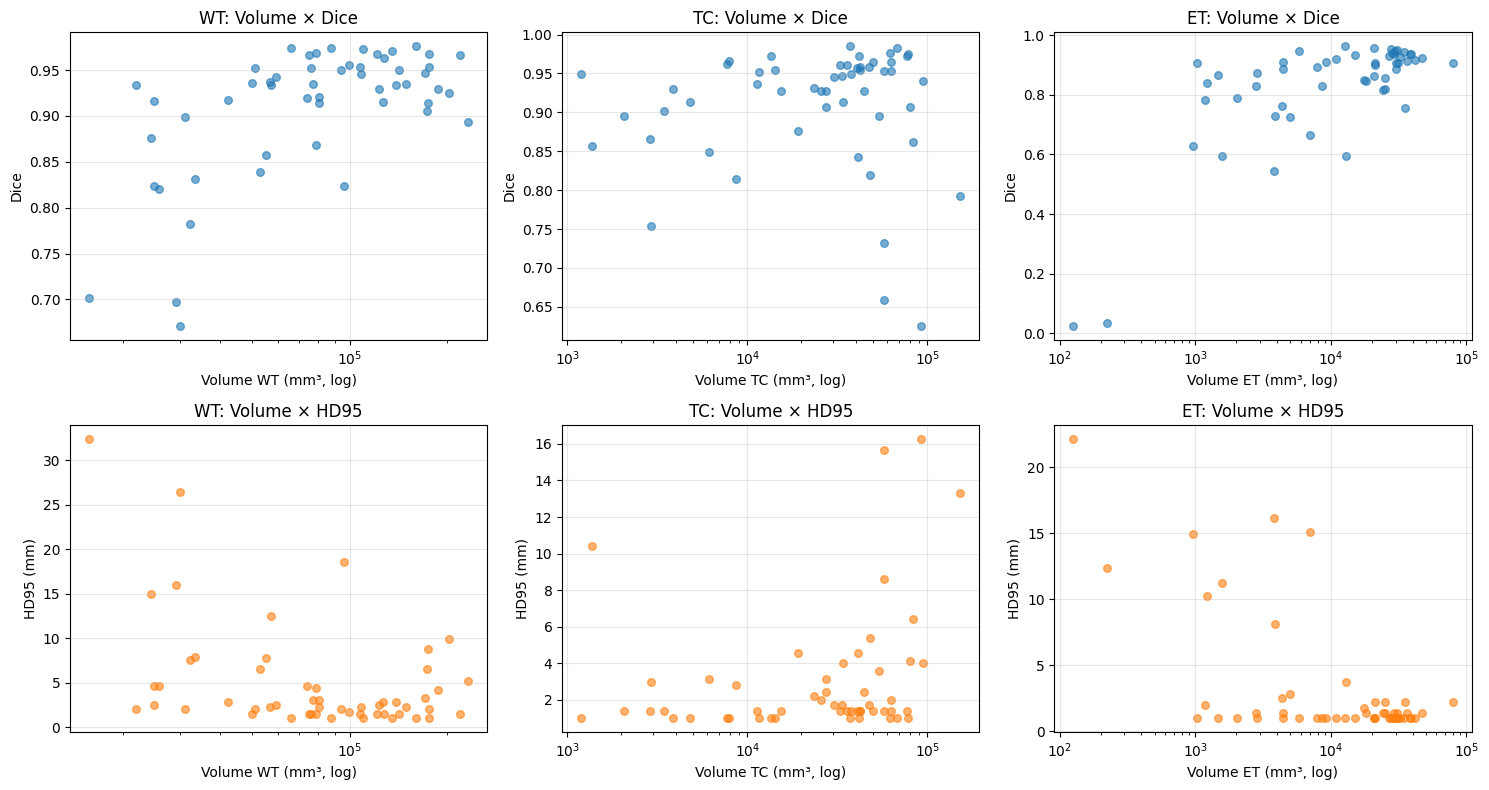

Correlação de Spearman entre volume tumoral e métricas:


,regiao,spearman_vol×dice,p_value_dice,spearman_vol×hd95,p_value_hd95
0,WT,0.466,0.0004,-0.300,0.0292
1,TC,0.145,0.3000,0.302,0.0278
2,ET,0.593,0.0000,-0.351,0.0099


In [24]:
# [3/6] Scatter: volume tumoral × Dice e × HD95 (por região) + correlação Spearman

regions = ["WT", "TC", "ET"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, reg in enumerate(regions):
    vol = df_err[f"vol_{reg}_mm3"].values
    dsc = df_err[f"dice_{reg}"].values
    hsc = df_err[f"hd95_{reg}"].values

    axes[0, j].scatter(vol, dsc, alpha=0.6, s=30)
    axes[0, j].set_xscale("log")
    axes[0, j].set_xlabel(f"Volume {reg} (mm³, log)")
    axes[0, j].set_ylabel("Dice")
    axes[0, j].set_title(f"{reg}: Volume × Dice")
    axes[0, j].grid(True, alpha=0.3)

    axes[1, j].scatter(vol, hsc, alpha=0.6, s=30, color="C1")
    axes[1, j].set_xscale("log")
    axes[1, j].set_xlabel(f"Volume {reg} (mm³, log)")
    axes[1, j].set_ylabel("HD95 (mm)")
    axes[1, j].set_title(f"{reg}: Volume × HD95")
    axes[1, j].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

corr_rows = []
for reg in regions:
    v = df_err[f"vol_{reg}_mm3"].values
    d = df_err[f"dice_{reg}"].values
    h = df_err[f"hd95_{reg}"].values

    rho_d, p_d = spearmanr(v, d)
    mask = ~np.isnan(h)
    if mask.sum() > 2:
        rho_h, p_h = spearmanr(v[mask], h[mask])
    else:
        rho_h, p_h = np.nan, np.nan

    corr_rows.append({
        "regiao": reg,
        "spearman_vol×dice": round(rho_d, 3),  "p_value_dice": round(p_d, 4),
        "spearman_vol×hd95": round(rho_h, 3),  "p_value_hd95": round(p_h, 4),
    })

print("Correlação de Spearman entre volume tumoral e métricas:")
pd.DataFrame(corr_rows)

In [25]:
# [4/6] Ranking dos piores casos: por Dice médio (WT/TC/ET) e por HD95 médio

K_WORST = 5

df_err["dice_mean"] = df_err[["dice_WT", "dice_TC", "dice_ET"]].mean(axis=1)
df_err["hd95_mean"] = df_err[["hd95_WT", "hd95_TC", "hd95_ET"]].mean(axis=1, skipna=True)

cols_show = ["id", "dice_WT", "dice_TC", "dice_ET",
             "hd95_WT", "hd95_TC", "hd95_ET",
             "vol_WT_mm3", "vol_ET_mm3", "size_bin"]

print(f"Top {K_WORST} piores casos por Dice médio (menor = pior):")
worst_dice = df_err.nsmallest(K_WORST, "dice_mean")[cols_show + ["dice_mean"]].round(3)
print(worst_dice.to_string(index=False))

print(f"\nTop {K_WORST} piores casos por HD95 médio (maior = pior):")
worst_hd95 = df_err.nlargest(K_WORST, "hd95_mean")[cols_show + ["hd95_mean"]].round(3)
print(worst_hd95.to_string(index=False))

worst_ids = list(dict.fromkeys(worst_dice["id"].tolist() + worst_hd95["id"].tolist()))
print(f"\nUnião (IDs únicos a visualizar): {len(worst_ids)} casos -> {worst_ids}")

Top 5 piores casos por Dice médio (menor = pior):
                  id  dice_WT  dice_TC  dice_ET  hd95_WT  hd95_TC  hd95_ET  vol_WT_mm3  vol_ET_mm3 size_bin  dice_mean
BraTS20_Training_291    0.966    0.732    0.025    1.414    8.602   22.144    218263.0       126.0   Grande      0.575
BraTS20_Training_271    0.952    0.932    0.035    2.000    2.236   12.401     51173.0       224.0  Pequeno      0.640
BraTS20_Training_316    0.894    0.626    0.595    5.196   16.279   11.252    231951.0      1585.0   Grande      0.705
BraTS20_Training_277    0.671    0.754    0.868   26.420    3.000    1.000     30073.0      1463.0  Pequeno      0.764
BraTS20_Training_301    0.905    0.659    0.730    6.481   15.652    8.124    173216.0      3873.0   Grande      0.765

Top 5 piores casos por HD95 médio (maior = pior):
                  id  dice_WT  dice_TC  dice_ET  hd95_WT  hd95_TC  hd95_ET  vol_WT_mm3  vol_ET_mm3 size_bin  hd95_mean
BraTS20_Training_308    0.926    0.793    0.665    9.849   13.342 

Plotando 1 dos 7 piores casos identificados.


Paciente: BraTS20_Training_291 | split=test | z=87
Dice C1 (necrose/non-enh): 0.7292
Dice C2 (edema):           0.7925
Dice ET (enhancing):       0.0253
Dice WT:                   0.9665
Dice TC:                   0.7323



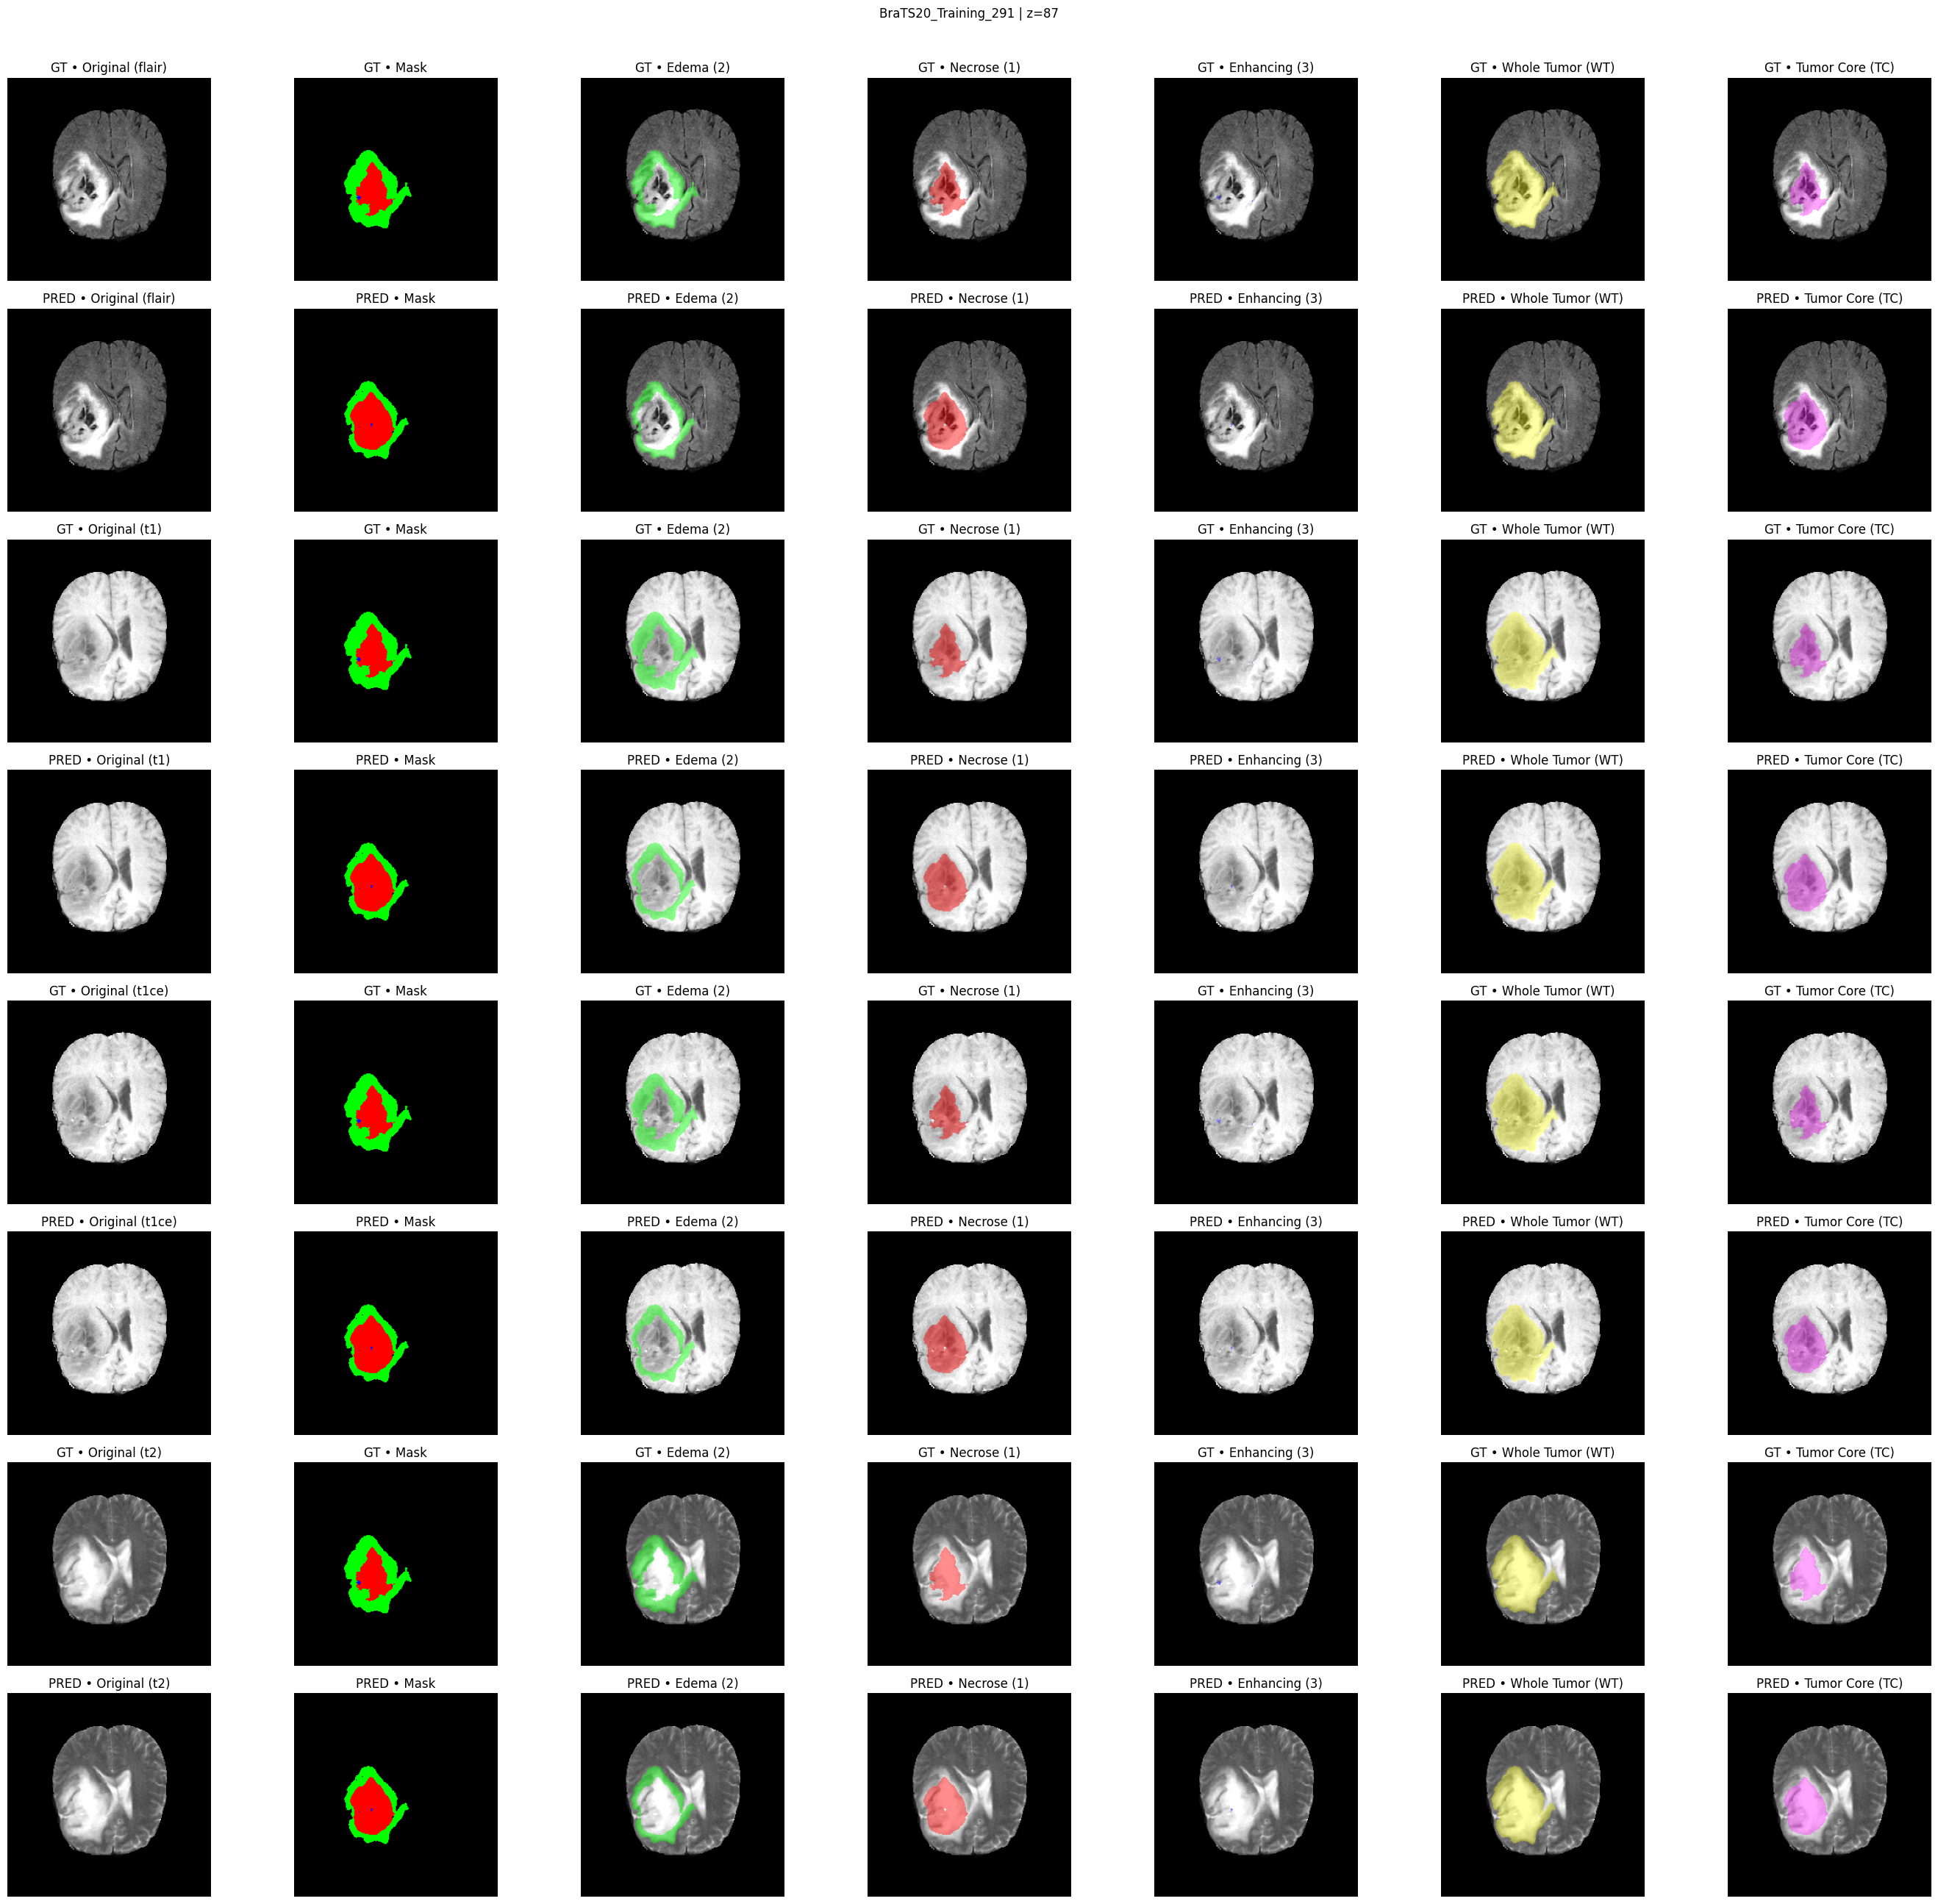

In [26]:
# [5/6] Visualização qualitativa dos piores casos

N_PLOT = min(1, len(worst_ids))
print(f"Plotando {N_PLOT} dos {len(worst_ids)} piores casos identificados.\n")

for cid in worst_ids[:N_PLOT]:
    print("=" * 80)
    plot_random_case_multimodal_gt_pred([cid], split_name="test", seed=0)

In [27]:
# [6/6] Análise de componentes conexos: lesões perdidas (FN) vs (FP) por caso

CC_MIN_SIZE = 50

def count_components(gt_mask, pr_mask, min_size=CC_MIN_SIZE):
    structure = np.ones((3, 3, 3), dtype=int)
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)

    n_gt_valid = sum(1 for g in range(1, n_gt + 1) if (gt_lab == g).sum() >= min_size)
    n_pr_valid = sum(1 for p in range(1, n_pr + 1) if (pr_lab == p).sum() >= min_size)

    matched_pred, n_missed = set(), 0
    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap = np.unique(pr_lab[gt_l]); overlap = overlap[overlap > 0]
        if len(overlap) == 0:
            n_missed += 1
        else:
            matched_pred.update(int(p) for p in overlap)

    n_spurious = sum(1 for p in range(1, n_pr + 1)
                     if p not in matched_pred and (pr_lab == p).sum() >= min_size)
    return n_gt_valid, n_pr_valid, n_missed, n_spurious


cc_rows = []
for cid in tqdm(test_ids, desc="Componentes conexos"):
    gt = load_arr(find_file(case_dir("test", cid), "seg")).astype(np.int16); gt[gt == 4] = 3
    pr = load_arr(get_pred_path(cid)).astype(np.int16);                       pr[pr == 4] = 3

    nw = count_components((gt==1)|(gt==2)|(gt==3), (pr==1)|(pr==2)|(pr==3))
    nt = count_components((gt==1)|(gt==3),         (pr==1)|(pr==3))
    ne = count_components((gt==3),                  (pr==3))

    cc_rows.append({"id": cid,
        "WT_n_gt": nw[0], "WT_n_pr": nw[1], "WT_missed_FN": nw[2], "WT_spurious_FP": nw[3],
        "TC_n_gt": nt[0], "TC_n_pr": nt[1], "TC_missed_FN": nt[2], "TC_spurious_FP": nt[3],
        "ET_n_gt": ne[0], "ET_n_pr": ne[1], "ET_missed_FN": ne[2], "ET_spurious_FP": ne[3],
    })

df_cc = pd.DataFrame(cc_rows)

print("Totais agregados (todos os casos):")
totals = pd.DataFrame({
    "região":          ["WT", "TC", "ET"],
    "tot_lesões_GT":   [df_cc["WT_n_gt"].sum(),       df_cc["TC_n_gt"].sum(),       df_cc["ET_n_gt"].sum()],
    "tot_lesões_PR":   [df_cc["WT_n_pr"].sum(),       df_cc["TC_n_pr"].sum(),       df_cc["ET_n_pr"].sum()],
    "tot_perdidas_FN": [df_cc["WT_missed_FN"].sum(),  df_cc["TC_missed_FN"].sum(),  df_cc["ET_missed_FN"].sum()],
    "tot_espúrias_FP": [df_cc["WT_spurious_FP"].sum(),df_cc["TC_spurious_FP"].sum(),df_cc["ET_spurious_FP"].sum()],
})
totals["FN_rate_%"] = (100 * totals["tot_perdidas_FN"] / totals["tot_lesões_GT"].replace(0, np.nan)).round(2)
totals["FP_rate_%"] = (100 * totals["tot_espúrias_FP"] / totals["tot_lesões_PR"].replace(0, np.nan)).round(2)
print(totals.to_string(index=False))

print("\nTop 10 casos com mais erros de componente (FN+FP somados em todas as regiões):")
df_cc["err_total"] = df_cc[["WT_missed_FN","TC_missed_FN","ET_missed_FN",
                            "WT_spurious_FP","TC_spurious_FP","ET_spurious_FP"]].sum(axis=1)
df_cc.nlargest(10, "err_total")

Componentes conexos: 100%|██████████| 53/53 [00:50<00:00,  1.06it/s]

Totais agregados (todos os casos):
região  tot_lesões_GT  tot_lesões_PR  tot_perdidas_FN  tot_espúrias_FP  FN_rate_%  FP_rate_%
    WT             89             94               23               24      25.84      25.53
    TC             63             59                4                0       6.35       0.00
    ET             78             69                9                3      11.54       4.35

Top 10 casos com mais erros de componente (FN+FP somados em todas as regiões):


,id,WT_n_gt,WT_n_pr,WT_missed_FN,WT_spurious_FP,TC_n_gt,TC_n_pr,TC_missed_FN,TC_spurious_FP,ET_n_gt,ET_n_pr,ET_missed_FN,ET_spurious_FP,err_total
24,BraTS20_Training_064,4,11,1,8,1,1,0,0,1,1,0,0,9
50,BraTS20_Training_175,4,2,2,0,4,1,3,0,4,1,3,0,8
0,BraTS20_Training_110,5,3,4,2,1,1,0,0,1,2,0,0,6
43,BraTS20_Training_308,1,3,0,2,1,1,0,0,5,3,3,1,6
1,BraTS20_Training_277,3,3,2,2,1,2,0,0,2,2,0,0,4
12,BraTS20_Training_213,4,2,3,1,1,1,0,0,1,1,0,0,4
42,BraTS20_Training_106,3,5,1,3,2,2,0,0,2,2,0,0,4
9,BraTS20_Training_008,2,1,1,0,2,1,1,0,2,1,1,0,3
40,BraTS20_Training_151,2,4,0,3,1,1,0,0,1,1,0,0,3
8,BraTS20_Training_119,4,4,2,0,1,1,0,0,1,1,0,0,2
